## Evaluate a custom Presidio Analyzer using the Presidio Evaluator framework

This notebook demonstrates how to evaluate a Presidio instance using the presidio-evaluator framework. It builds upon [notebook 4](4_Evaluate_Presidio_Analyzer.ipynb), customising the `PresidioAnalyzer` instance for better accuracy. For more on customising Presidio, see the [Presidio Analyzer documentation](https://data-privacy-stack.github.io/presidio/analyzer/).

Steps:
1. Load dataset
2. Dataset statistics
3. Define the custom Presidio Analyzer
4. Run predictions
5. Review and adjust entity mapping
6. Evaluate
7. Results and error analysis

In [3]:
# install presidio evaluator via pip if not yet installed

#!pip install presidio-evaluator
#!pip install "presidio-analyzer[transformers]"

In [4]:
import json
import warnings
from collections import Counter
from pathlib import Path
from pprint import pprint

warnings.filterwarnings('ignore')

import pandas as pd
from presidio_analyzer import (
    AnalyzerEngine,
    Pattern,
    PatternRecognizer,
    RecognizerRegistry,
)
from presidio_analyzer.context_aware_enhancers import LemmaContextAwareEnhancer
from presidio_analyzer.nlp_engine import SlimSpacyNlpEngine
from presidio_analyzer.predefined_recognizers.ner import HuggingFaceNerRecognizer

from presidio_evaluator import InputSample
from presidio_evaluator.entity_mapping import CanonicalMapper
from presidio_evaluator.evaluation import ModelError, Plotter, SpanEvaluator
from presidio_evaluator.experiment_tracking import get_experiment_tracker
from presidio_evaluator.models import PresidioAnalyzerWrapper

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

%reload_ext autoreload
%autoreload 2
%matplotlib inline


## 1. Load dataset from file

In [5]:
dataset_name = "synth_dataset_v2.json"
dataset = InputSample.read_dataset_json(Path(Path.cwd().parent, "data", dataset_name))

print(len(dataset))

tokenizing input:   0%|          | 0/1500 [00:00<?, ?it/s]

loading model en_core_web_sm


tokenizing input: 100%|██████████| 1500/1500 [00:04<00:00, 302.00it/s]

1500


This dataset was auto generated. See more info here [Synthetic data generation](1_Generate_data.ipynb).

In [6]:
def get_entity_counts(dataset: list[InputSample]) -> dict:
    """Return a dictionary with counter per entity type."""
    entity_counter = Counter()
    for sample in dataset:
        for tag in sample.tags:
            entity_counter[tag] += 1
    return entity_counter

## 2. Simple dataset statistics

In [7]:
entity_counts = get_entity_counts(dataset)
print("Count per entity:")
pprint(entity_counts.most_common(), compact=True)

print(
    "\nMin and max number of tokens in dataset: "
    f"Min: {min([len(sample.tokens) for sample in dataset])}, "
    f"Max: {max([len(sample.tokens) for sample in dataset])}"
)

print(
    f"Min and max sentence length in dataset: "
    f"Min: {min([len(sample.full_text) for sample in dataset])}, "
    f"Max: {max([len(sample.full_text) for sample in dataset])}"
)

Count per entity:
[('O', 19626), ('STREET_ADDRESS', 3071), ('PERSON', 1369), ('GPE', 521),
 ('ORGANIZATION', 504), ('PHONE_NUMBER', 350), ('DATE_TIME', 219),
 ('TITLE', 142), ('CREDIT_CARD', 136), ('US_SSN', 80), ('AGE', 74), ('NRP', 55),
 ('ZIP_CODE', 50), ('EMAIL_ADDRESS', 49), ('DOMAIN_NAME', 37),
 ('IP_ADDRESS', 22), ('IBAN_CODE', 21), ('US_DRIVER_LICENSE', 9)]

Min and max number of tokens in dataset: Min: 3, Max: 78
Min and max sentence length in dataset: Min: 9, Max: 407


## 3. Define the AnalyzerEngine object 
In this case, we customize the AnalyzerEngine to use a different NER model, some custom recognizers and the context aware enhancer.

### 3.1 Set up the NlpEngine and Hugging Face NER Recognizer
The NLP engine uses spaCy for text processing (lemmas, tokens, etc.). The Hugging Face model is added as a direct recognizer (HuggingFaceNerRecognizer) instead of being part of the NLP engine. This approach gives better control over model predictions.

In [8]:
# Defin a slim Nlp Engine (we're using a Presidio recognizer instead of a Presidio NLP Engine)
nlp_engine = SlimSpacyNlpEngine()
nlp_engine.load()

In [9]:
# # Map OpenMed model entities to Presidio entities
mapping = {
    # Personal Info - Names & Demographics
    "first_name": "FIRST_NAME",
    "last_name": "LAST_NAME",
    "age": "AGE",
    "gender": "GENDER",
    "date_of_birth": "DATE_OF_BIRTH",
    "blood_type": "BLOOD_TYPE",
    "occupation": "OCCUPATION",
    "education_level": "EDUCATION_LEVEL",
    "employment_status": "EMPLOYMENT_STATUS",
    "language": "LANGUAGE",
    "race_ethnicity": "ETHNICITY",
    "sexuality": "SEXUALITY",
    "political_view": "POLITICAL_VIEW",
    "religious_belief": "RELIGIOUS_BELIEF",
    "biometric_identifier": "BIOMETRIC_IDENTIFIER",
    "pin": "ID",
    # Identifiers (20+ types)
    "account_number": "ACCOUNT_NUMBER",  # FINANCIAL_PII branch (bank/IBAN accounts), not generic ID
    "customer_id": "ID",
    "employee_id": "ID",
    "unique_id": "ID",
    "bank_routing_number": "US_BANK_NUMBER",
    "swift_bic": "SWIFT_CODE",
    "certificate_license_number": "PROFESSIONAL_LICENSE",  # GOVERNMENT_ID branch (matches US_DRIVER_LICENSE), not PHI
    "medical_record_number": "MEDICAL_LICENSE",
    "health_plan_beneficiary_number": "ID",
    "credit_debit_card": "CREDIT_CARD",
    "cvv": "CVV",
    "ssn": "US_SSN",
    "tax_id": "ID",
    "license_plate": "LICENSE_PLATE",
    "vehicle_identifier": "ID",
    "mac_address": "ID",
    "device_identifier": "ID",
    # Authentication & Security
    "password": "PASSWORD",
    "user_name": "USER_NAME",
    # Contact Info (4 types)
    "email": "EMAIL_ADDRESS",
    "phone_number": "PHONE_NUMBER",
    "fax_number": "PHONE_NUMBER",
    "url": "URL",
    # Location (6 types)
    "city": "CITY",
    "country": "COUNTRY",
    "county": "COUNTY",
    "state": "STATE",
    "street_address": "STREET_ADDRESS",
    "coordinate": "COORDINATE",
    "postcode": "ZIP_CODE",
    # Network Info
    "ipv4": "IP_ADDRESS",
    "ipv6": "IP_ADDRESS",
    # Temporal (3 types)
    "date": "DATE_TIME",
    "date_time": "DATE_TIME",
    "time": "DATE_TIME",
    # Organization (1 type)
    "company_name": "COMPANY",
}


### 3.2 Set up the relevant recognizers
Add and remove recognizers to fit the dataset in hand. 
Removing all the recognizers that don't map to entities in our dataset.

In [10]:
ner_recognizer = HuggingFaceNerRecognizer(
        model_name="OpenMed/OpenMed-PII-SuperClinical-Large-434M-v1",
        label_mapping=mapping,
        aggregation_strategy="first"
    )

# another option: OpenMed/OpenMed-PII-BioClinicalModern-Base-149M-v1

def get_titles_recognizer():
    titles_recognizer = PatternRecognizer(
        deny_list=["Mr.", "Mrs.", "Ms.", "Miss", "Dr.", "Prof."],
        supported_entity="TITLE",
        name="TitlesRecognizer",
    )
    return titles_recognizer


def get_years_recognizer():
    years_recognizer = PatternRecognizer(
        patterns=[Pattern("YEAR", r"\b(19|20)\d{2}\b", score=0.1)],
        supported_entity="DATE_TIME",
        name="YearsRecognizer",
        context=["year", "at", "date", "in", "on"],
    )
    return years_recognizer


def get_age_recognizer():
    weak_regex = r"\b(110|[1-9]?[0-9])\b"
    age_pattern = Pattern(name="age (very weak)", regex=weak_regex, score=0.01)
    age_recognizer = PatternRecognizer(
        supported_entity="AGE",
        patterns=[age_pattern],
        name="AgeRecognizer",
        context=["month", "old", "turn", "age", "y/o"],
    )
    return age_recognizer


# Create Recognizer Registry
registry = RecognizerRegistry()
registry.load_predefined_recognizers(nlp_engine=nlp_engine)

# Add custom pattern recognizers
registry.add_recognizer(ner_recognizer)
registry.add_recognizer(get_titles_recognizer())
registry.add_recognizer(get_years_recognizer())
registry.add_recognizer(get_age_recognizer())

# Remove unnecessary recognizers from presidio
unnecessary = [
    "NhsRecognizer",
    "UkNinoRecognizer",
    "SgFinRecognizer",
    "AuAbnRecognizer",
    "AuAcnRecognizer",
    "AuTfnRecognizer",
    "AuMedicareRecognizer",
    "InPanRecognizer",
    "InAadhaarRecognizer",
    "InVehicleRegistrationRecognizer",
    "InPassportRecognizer",
    "InVoterRecognizer",
    "CryptoRecognizer",
    "SpacyRecognizer",
]

for rec in unnecessary:
    registry.remove_recognizer(rec)

Device set to use cpu


### 3.3 Configure the context mechanism
Configure the `LemmaContextAawareEnhancer` which uses surrounding words to increase confidence in detection

In [11]:
# Set up the context aware enhancer
context_enhancer = LemmaContextAwareEnhancer(
    context_prefix_count=10, context_suffix_count=10
)

### 3.4 Create the AnalyzerEngine object

In [12]:
# Set up the engine and other PII recognizers
analyzer_engine = AnalyzerEngine(
    nlp_engine=nlp_engine,
    context_aware_enhancer=context_enhancer,
    registry=registry,
    default_score_threshold=0.3,
)

# analyzer_engine = AnalyzerEngine()

pprint("Supported entities for English:")
pprint(analyzer_engine.get_supported_entities("en"), compact=True)

print("\nLoaded recognizers for English:")
pprint(
    [
        rec.name
        for rec in analyzer_engine.registry.get_recognizers("en", all_fields=True)
    ],
    compact=True,
)

print("\nLoaded Context Aware Enhancer:")
print(analyzer_engine.context_aware_enhancer.__class__.__name__)
pprint(json.dumps(analyzer_engine.context_aware_enhancer.__dict__), compact=True)


'Supported entities for English:'
['US_DRIVER_LICENSE', 'SEXUALITY', 'MAC_ADDRESS', 'MEDICAL_LICENSE', 'US_ITIN',
 'COORDINATE', 'LANGUAGE', 'SWIFT_CODE', 'ACCOUNT_NUMBER', 'URL',
 'PHONE_NUMBER', 'COUNTY', 'FIRST_NAME', 'LICENSE_PLATE', 'US_SSN',
 'EDUCATION_LEVEL', 'DATE_TIME', 'COMPANY', 'IP_ADDRESS', 'STATE', 'BLOOD_TYPE',
 'COUNTRY', 'OCCUPATION', 'GENDER', 'EMAIL_ADDRESS', 'PROFESSIONAL_LICENSE',
 'PASSWORD', 'USER_NAME', 'POLITICAL_VIEW', 'RELIGIOUS_BELIEF', 'ID',
 'IBAN_CODE', 'CITY', 'TITLE', 'CREDIT_CARD', 'STREET_ADDRESS', 'US_PASSPORT',
 'EMPLOYMENT_STATUS', 'AGE', 'BIOMETRIC_IDENTIFIER', 'DATE_OF_BIRTH',
 'ETHNICITY', 'LAST_NAME', 'CVV', 'ZIP_CODE', 'US_BANK_NUMBER']

Loaded recognizers for English:
['CreditCardRecognizer', 'UsBankRecognizer', 'UsLicenseRecognizer',
 'UsItinRecognizer', 'UsPassportRecognizer', 'UsSsnRecognizer',
 'DateRecognizer', 'EmailRecognizer', 'IbanRecognizer', 'IpRecognizer',
 'MedicalLicenseRecognizer', 'MacAddressRecognizer', 'PhoneRecognizer',
 '

In [13]:
# Test Analyzer
text = "Yesterday in Mt. Sinai AP: Dana Silver, 79 years old female was complaining of stomach pain. Her ID is 154555"
res = analyzer_engine.analyze(text=text, language="en", return_decision_process=True)
for result in res:
    print(f"Entity: {result.entity_type}, Text: {text[result.start : result.end]}")

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Entity: FIRST_NAME, Text:  Dana
Entity: LAST_NAME, Text:  Silver,
Entity: AGE, Text:  79
Entity: CITY, Text:  Mt. Sinai
Entity: ID, Text:  154555
Entity: GENDER, Text:  female


In [14]:
# Wrap the analyzer
wrapped_analyzer = PresidioAnalyzerWrapper(
    analyzer_engine=analyzer_engine,
    score_threshold=analyzer_engine.default_score_threshold,
    language="en",
)

## 4. Run predictions

Run the model on the full dataset. Returns a 5-column DataFrame (`sentence_id`, `token`, `annotation`, `prediction`, `start_indices`).

In [15]:
results_df = wrapped_analyzer.predict_dataset(dataset)
results_df.head()

,sentence_id,token,annotation,prediction,start_indices
0,0,The,O,O,0
1,0,address,O,O,4
2,0,of,O,O,12
3,0,Persint,ORGANIZATION,FIRST_NAME,15
4,0,is,O,O,23


## 5. Review entity mapping

- The entity mapping process auto-resolves labels using a hierarchical entity tree.
The `CanonicalMapper` class analyzes the results (predictions and annotations), and checks if there are any gaps towards the evaluation process.

- If you call `render_html()` to inspect issues, you'd see if there are any gaps that prevent you from completing the evaluation successfully. Make sure you address all the issues by using:
  -  `mapper.map({"LABEL": "CANONICAL"})` to remap or 
  -  `mapper.map({"LABEL": None})` to suppress.

- For more information about entity mapping, see [Notebook 6 - Entity Mapping](6_Interactive_Entity_Mapping.ipynb).

In [16]:
# Analyze the results DataFrame.
# min_collision_count suppresses COLLISION_CROSS_BRANCH warnings with fewer
# cross-branch token co-occurrences than the threshold (rare label overlaps).
mapper = CanonicalMapper()
mapper.analyze(results_df, min_collision_count=5)
mapper.render_html()

Label,Resolved as,Tokens
STREET_ADDRESS,ADDRESS,3071
PERSON,PERSON,1369
GPE,GPE,521
ORGANIZATION,ORGANIZATION,504
PHONE_NUMBER,PHONE_NUMBER,350
DATE_TIME,DATE_TIME,219
TITLE,TITLE,142
CREDIT_CARD,FINANCIAL,136
US_SSN,SSN,80
AGE,AGE,74


In [17]:
# Suppress all those entities that the model detects but the dataset doesn't have annotations for (prediction-only labels)
mapper.suppress_prediction_only()

In [18]:
# Resolve all blocking (WARNING+) issues. Adjust mappings for your model's labels.
# PREDICTION_ONLY and COLLISION_CROSS_BRANCH are suppressed here — remap if appropriate.
resolutions = {}
for issue in mapper.get_issues():
    if issue.severity.value in ("warning", "error"):
        for lbl in issue.labels:
            resolutions[lbl] = None  # suppress — adjust as needed

if resolutions:
    mapper.map(resolutions)

mapped_results = mapper.get_mapped_results_dataframe()
mapper.render_html()

Label,Resolved as,Tokens
STREET_ADDRESS,ADDRESS,3071
PERSON,PERSON,1369
GPE,GPE,521
ORGANIZATION,ORGANIZATION,504
PHONE_NUMBER,PHONE_NUMBER,350
DATE_TIME,DATE_TIME,219
TITLE,TITLE,142
CREDIT_CARD,FINANCIAL,136
US_SSN,SSN,80
AGE,AGE,74


## 6. Evaluate

In [19]:
# Set up the experiment tracker and log model + dataset params
experiment = get_experiment_tracker()
params = {"dataset_name": dataset_name, "model_name": wrapped_analyzer.name}
params.update(wrapped_analyzer.to_log())
experiment.log_parameters(params)
experiment.log_dataset_hash(dataset)
experiment.log_parameter("entity_mappings", json.dumps(mapper.get_mapping()))

evaluator = SpanEvaluator(iou_threshold=0.75)
f_beta = 2  # F-beta parameter used throughout evaluation

skip words not provided, using default skip words. If you want the evaluation to not use skip words, pass skip_words=[]


In [20]:
hierarchical_results = evaluator.calculate_hierarchical_scores(
    mapped_results,
    beta=f_beta
    )
binary_results = hierarchical_results["binary"]
branch_results = hierarchical_results["branch"]
detailed_results = hierarchical_results["detailed"]

# Log detailed-level metrics to experiment tracker
experiment.log_metrics(detailed_results.to_log())
entities, confmatrix = detailed_results.to_confusion_matrix()
experiment.log_confusion_matrix(matrix=confmatrix, labels=entities)
experiment.end()

# A. Binary PII/O metrics
print("Level: binary (PII vs O):")
pprint({
    "Precision": round(binary_results.pii_precision, 3),
    "Recall":    round(binary_results.pii_recall, 3),
    f"F{f_beta}":  round(binary_results.pii_f, 3),
})

saving experiment data to /presidio-research/notebooks/experiment_20260723-102549.json
Level: binary (PII vs O):
{'F2': 0.91, 'Precision': 0.921, 'Recall': 0.907}


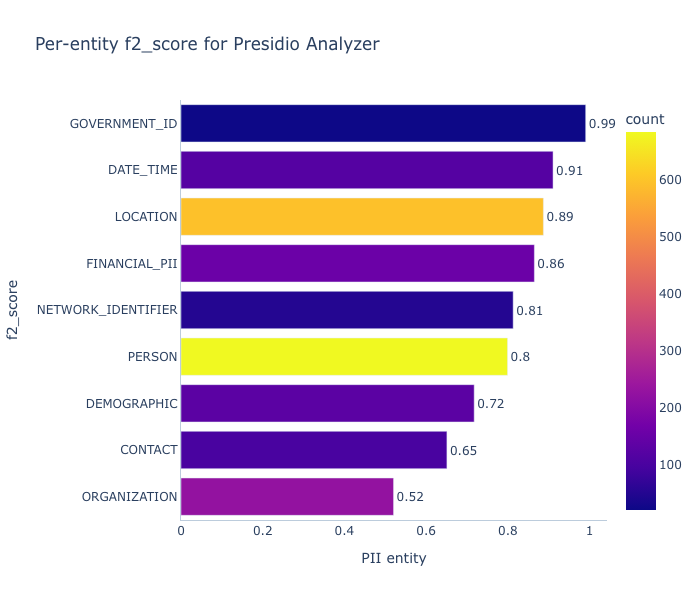

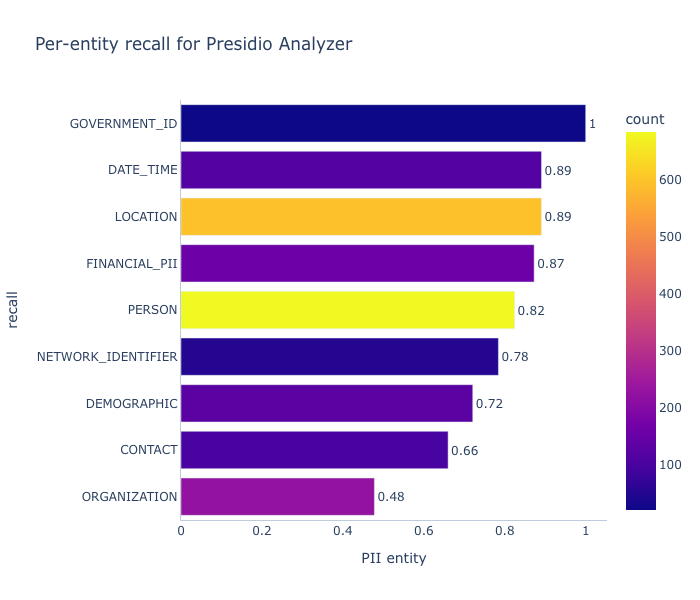

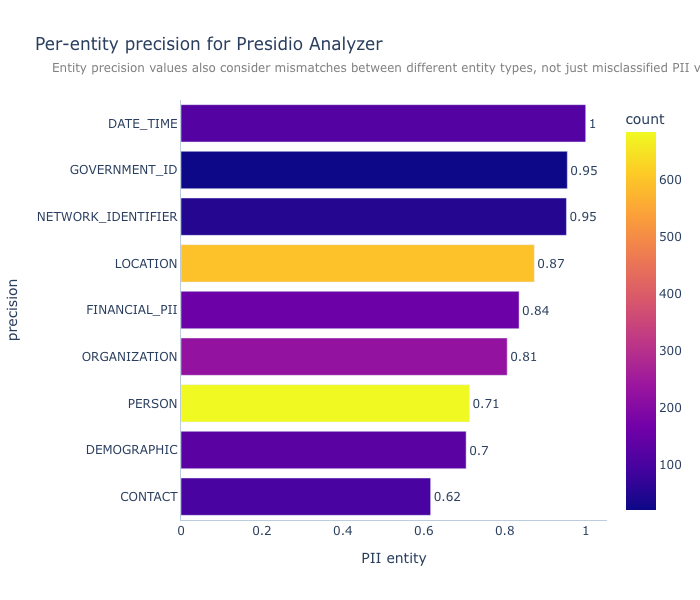

In [ ]:
# B. Branch-level per-entity scores (PERSON, LOCATION, DATE_TIME, …)
branch_plotter = Plotter(
    results=branch_results,
    model_name=wrapped_analyzer.name,
    display_mode="interactive",
    beta=f_beta,
)
branch_plotter.plot_scores(include_pii_aggregate=False, annotation_entities_only=True)

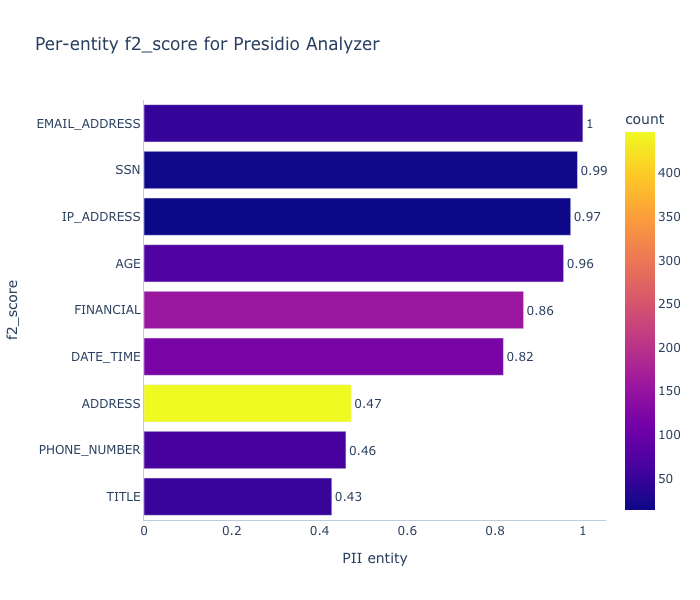

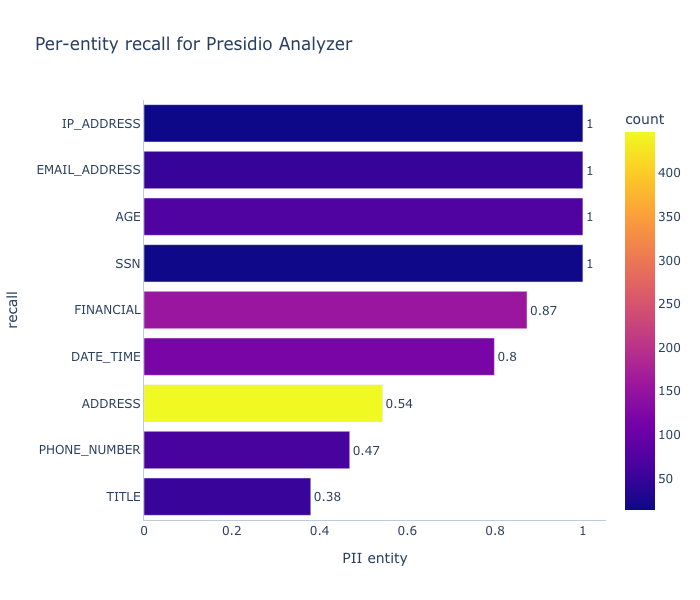

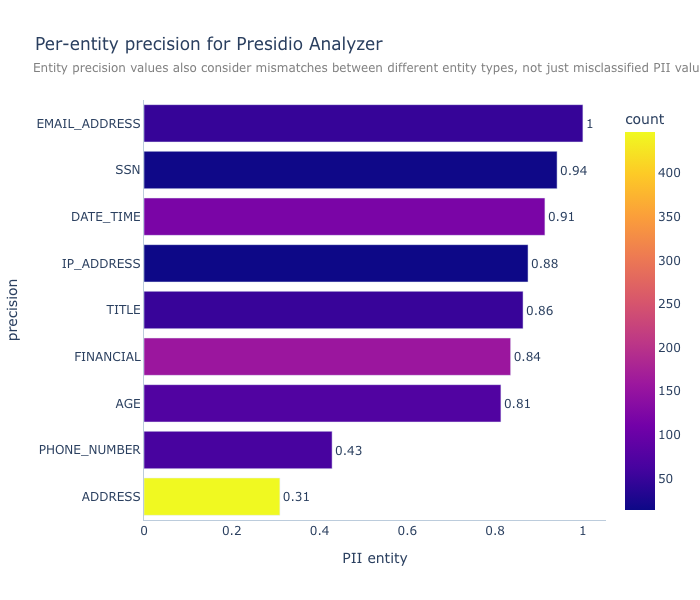

In [ ]:
# C. Detailed-level per-entity scores (NAME, GPE, PHONE_NUMBER, …)
detailed_plotter = Plotter(
    results=detailed_results,
    model_name=wrapped_analyzer.name,
    display_mode="interactive",
    beta=f_beta,
)
detailed_plotter.plot_scores(include_pii_aggregate=False, annotation_entities_only=True)

## 7. Confusion matrix

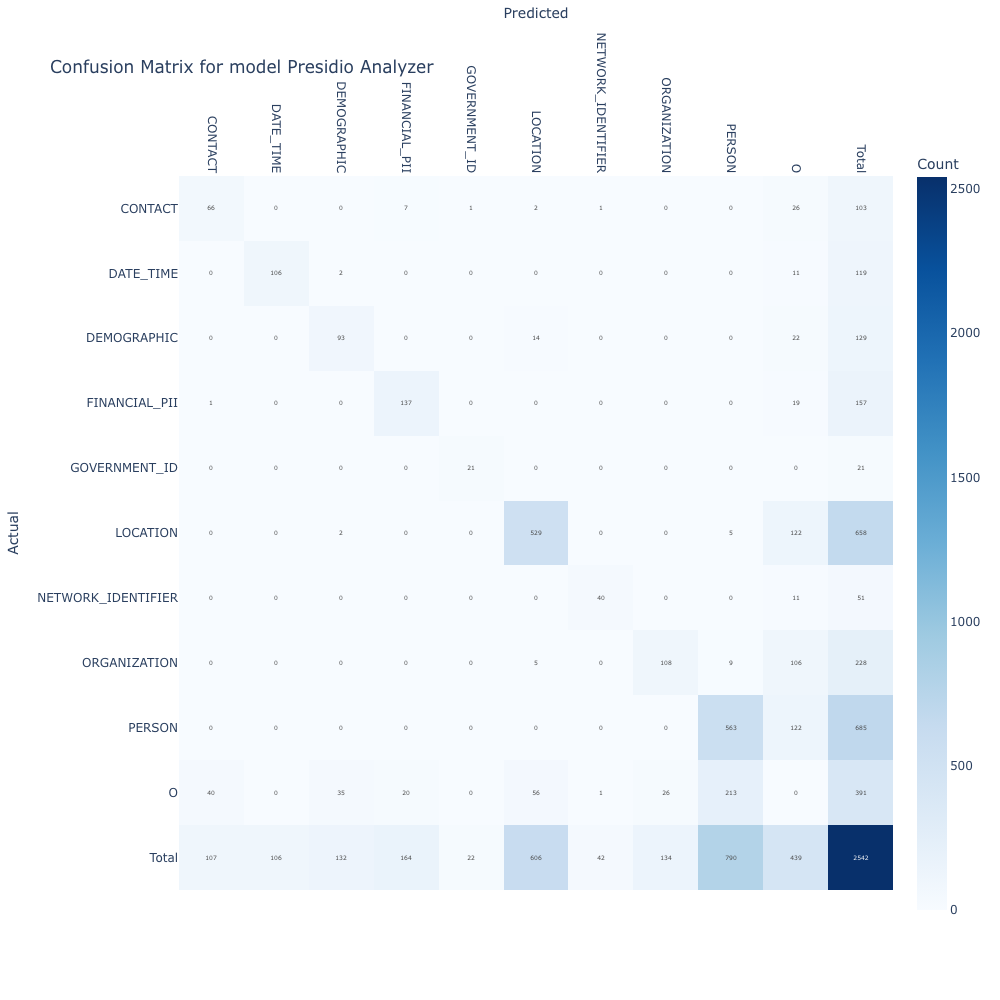

In [23]:
# D. Branch-level confusion matrix (only branch entities that appear in the data)
entities, confmatrix = branch_results.to_confusion_matrix()
branch_plotter.plot_confusion_matrix(entities=entities, confmatrix=confmatrix)

## 8. Error analysis

The `ModelError` class groups similar errors together, finding all the false positive and false negative predictions where the model's behavior is consistent. 

This can help in detecting patterns in the model's performance, such as:
- Consistent labeling of specific words or patterns  
- Systematic overprediction or underprediction

**Note:** All errors are displayed using the **mapped model entity types** (e.g., `LOCATION`, `PERSON`) rather than the original dataset entity types (e.g., `STREET_ADDRESS`, `GPE`). This ensures consistency with how the model was evaluated.

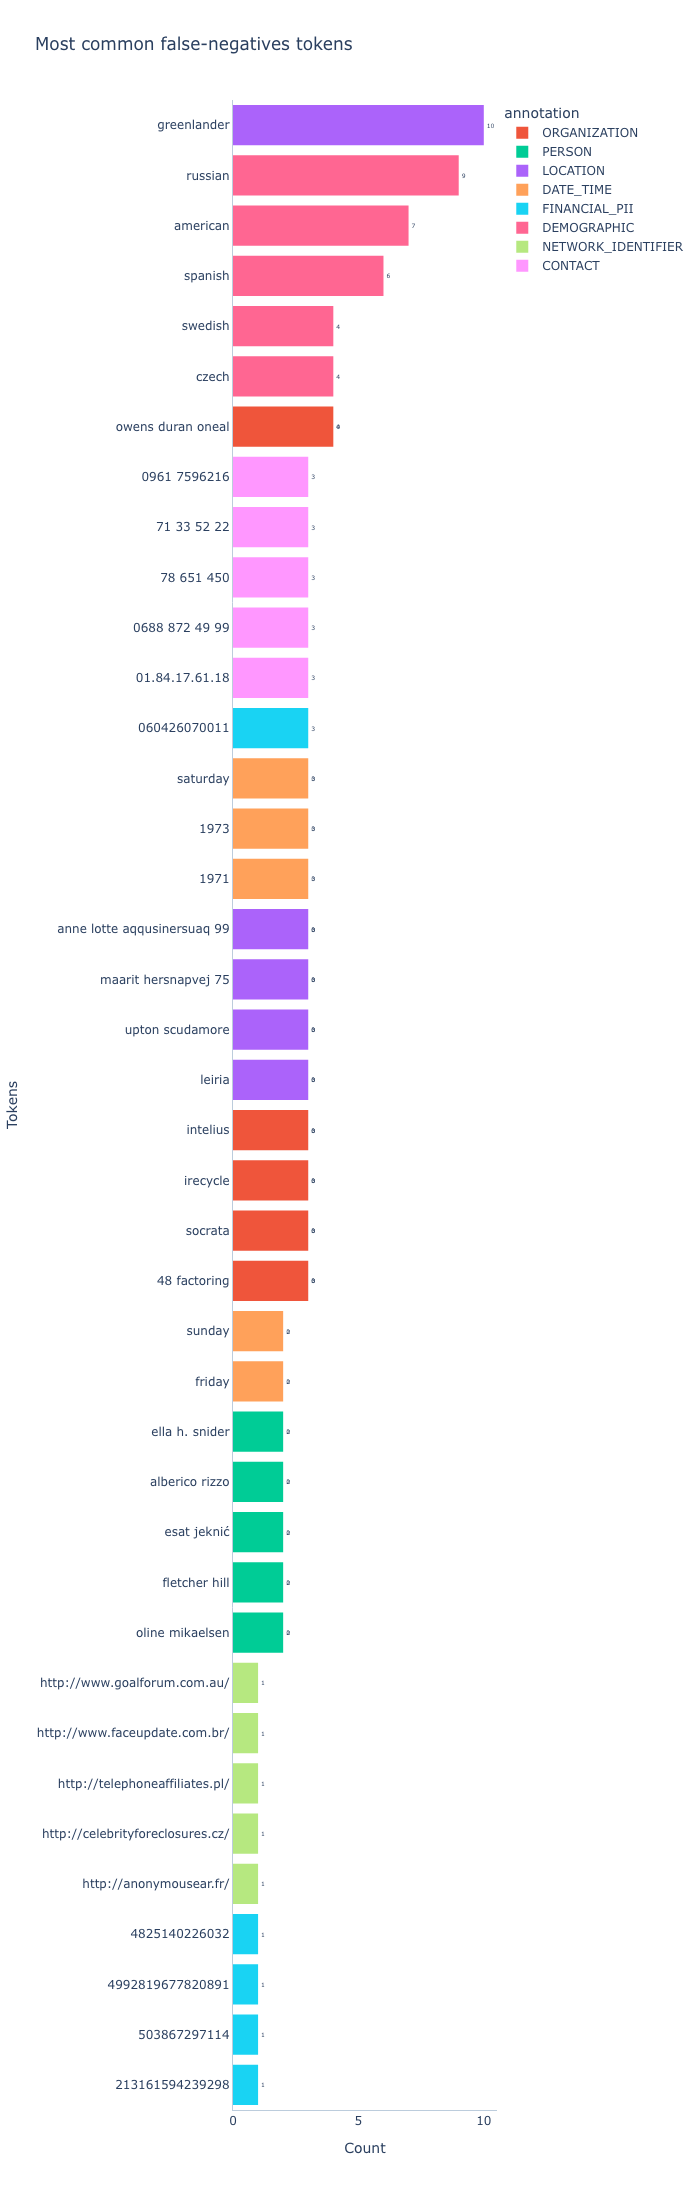

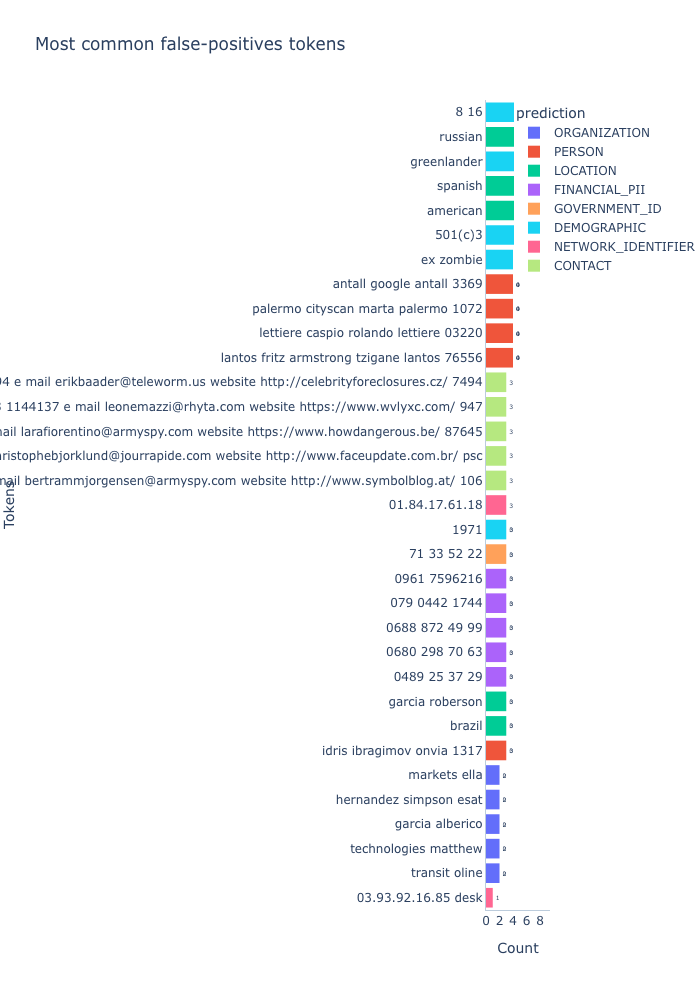

In [24]:
branch_plotter.plot_most_common_tokens()

### 8a. False positives
#### Most common false positive tokens:

In [25]:
ModelError.most_common_fp_tokens(branch_results.model_errors)

Most common false positive tokens:
[('8 16', 9),
 ('greenlander', 8),
 ('russian', 6),
 ('501(c)3', 5),
 ('antall google antall 3369', 4),
 ('ex zombie', 4),
 ('spanish', 4),
 ('american', 4),
 ('palermo cityscan marta palermo 1072', 4),
 ('lantos fritz armstrong tzigane lantos 76556', 4)]
---------------
Example sentence with each FP token:
	- 8 16 (`8 16` pred as DEMOGRAPHIC)
	- Greenlander (`greenlander` pred as DEMOGRAPHIC)
	- Russian (`russian` pred as LOCATION)
	- 501(c)3 (`501(c)3` pred as DEMOGRAPHIC)
	- Antall 
 > Google Antall 
 > 3369 (`antall google antall 3369` pred as PERSON)
	- ex - Zombie (`ex zombie` pred as DEMOGRAPHIC)
	- Spanish (`spanish` pred as LOCATION)
	- American (`american` pred as LOCATION)
	- Palermo 
 > Cityscan 
 > Marta Palermo 
 > 1072 (`palermo cityscan marta palermo 1072` pred as PERSON)
	- Lantos 
 > Fritz - Armstrong 
 > Tzigane Lantos 
 > 76556 (`lantos fritz armstrong tzigane lantos 76556` pred as PERSON)


[('8 16', 9),
 ('greenlander', 8),
 ('russian', 6),
 ('501(c)3', 5),
 ('antall google antall 3369', 4),
 ('ex zombie', 4),
 ('spanish', 4),
 ('american', 4),
 ('palermo cityscan marta palermo 1072', 4),
 ('lantos fritz armstrong tzigane lantos 76556', 4)]

#### More FP analysis

In [26]:
fps_df = ModelError.get_fps_dataframe(branch_results.model_errors, entity="PERSON")
fps_df[["full_text", "token", "annotation", "prediction"]].head(20)

,full_text,token,annotation,prediction
0,Persint,persint,O,PERSON
1,Mary ?,mary,O,PERSON
2,William Hughes \n\n 20789,william hughes 20789,O,PERSON
3,William Hughes \n\n 20789,william hughes 20789,O,PERSON
4,Avalara,avalara,O,PERSON
5,UPTON SCUDAMORE,upton scudamore,O,PERSON
6,Janka Szász \n\n Network,janka szász network,O,PERSON
7,"Marie Langrová ,",marie langrová,O,PERSON
8,Davis,davis,O,PERSON
9,Gregory Kudryashov \n\n 233,gregory kudryashov 233,O,PERSON


### 8b. False negatives (FN)

#### Most common false negative examples + a few samples with FN

In [27]:
ModelError.most_common_fn_tokens(branch_results.model_errors, n=15)

Most common false negative tokens:
[('greenlander', 7),
 ('russian', 6),
 ('american', 5),
 ('spanish', 4),
 ('saturday', 3),
 ('owens duran oneal', 3),
 ('allianz', 3),
 ('czech', 3),
 ('swedish', 3),
 ('persint', 2),
 ('avalara', 2),
 ('upton scudamore', 2),
 ('evidera', 2),
 ('peerj', 2),
 ('0494 92 82 32', 2)]
---------------
Example sentence with each FN token:
	- Greenlander (`greenlander` annotated as LOCATION)
	- Russian (`russian` annotated as DEMOGRAPHIC)
	- American (`american` annotated as DEMOGRAPHIC)
	- Spanish (`spanish` annotated as DEMOGRAPHIC)
	- Saturday (`saturday` annotated as DATE_TIME)
	- owens , duran and oneal (`owens duran oneal` annotated as ORGANIZATION)
	- Allianz (`allianz` annotated as ORGANIZATION)
	- Czech (`czech` annotated as DEMOGRAPHIC)
	- Swedish (`swedish` annotated as DEMOGRAPHIC)
	- Persint (`persint` annotated as ORGANIZATION)
	- Avalara (`avalara` annotated as ORGANIZATION)
	- UPTON SCUDAMORE (`upton scudamore` annotated as LOCATION)
	- Evider

[('greenlander', 7),
 ('russian', 6),
 ('american', 5),
 ('spanish', 4),
 ('saturday', 3),
 ('owens duran oneal', 3),
 ('allianz', 3),
 ('czech', 3),
 ('swedish', 3),
 ('persint', 2),
 ('avalara', 2),
 ('upton scudamore', 2),
 ('evidera', 2),
 ('peerj', 2),
 ('0494 92 82 32', 2)]

#### More FN analysis

In [28]:
fns_df = ModelError.get_fns_dataframe(branch_results.model_errors, entity="PERSON")

In [29]:
fns_df[["full_text", "token", "annotation", "prediction"]].head(20)

,full_text,token,annotation,prediction
0,Ubul Nicole Mary John,ubul nicole mary john,PERSON,O
1,William Hughes,william hughes,PERSON,O
2,Meza,meza,PERSON,O
3,Janka M. Szász Network and computer systems administrator,janka m. szász network computer systems administrator,PERSON,O
4,Marie Langrová Packager,marie langrová packager,PERSON,O
5,Halldór Matthew Kelly Melanie,halldór matthew kelly melanie,PERSON,O
6,Tomomi,tomomi,PERSON,O
7,Toshimi Arata,toshimi arata,PERSON,O
8,Stephan M Urner,stephan m urner,PERSON,O
9,Maureen Thibault,maureen thibault,PERSON,O
